# L10d Lab: UCB1 versus Thompson Sampling

> **Learning objectives**
>
> - Run two ordinary Bernoulli-bandit algorithms on identical arms and horizons.
> - Inspect pull counts and value estimates.
> - Compare expected regret without demanding identical random rewards.
> - Verify seeded reproducibility.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week10Core` module from [`../src/Week10Core.jl`](../src/Week10Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this lab's local source are loaded. The cell below fixes the bandit in `arm_probabilities::Vector{Float64}` and the budget in `horizon::Int64`, then runs both algorithms from the same seed into `ucb::NamedTuple` and `thompson::NamedTuple`. Each carries `counts::Vector{Int64}`, `estimates::Vector{Float64}`, `total_reward::Int64`, and `expected_regret::Float64`, compared in `summary::DataFrame`.


In [2]:
arm_probabilities = [0.30, 0.45, 0.55, 0.70]
horizon = 2000
ucb = run_bandit(arm_probabilities, horizon; algorithm = :ucb1, seed = 5800)
thompson = run_bandit(arm_probabilities, horizon; algorithm = :thompson, seed = 5800)

summary = DataFrame(
    algorithm = ["UCB1", "Thompson"],
    reward = [ucb.total_reward, thompson.total_reward],
    expected_regret = [ucb.expected_regret, thompson.expected_regret],
    best_arm_pulls = [ucb.counts[4], thompson.counts[4]],
)
pretty_table(summary)


┌───────────┬────────┬─────────────────┬────────────────┐
│ algorithm │ reward │ expected_regret │ best_arm_pulls │
│    String │  Int64 │         Float64 │          Int64 │
├───────────┼────────┼─────────────────┼────────────────┤
│      UCB1 │   1286 │          109.85 │           1502 │
│  Thompson │   1390 │            21.4 │           1886 │
└───────────┴────────┴─────────────────┴────────────────┘


In [3]:
@test sum(ucb.counts) == horizon
@test sum(thompson.counts) == horizon
@test argmax(ucb.counts) == 4
@test argmax(thompson.counts) == 4
@test ucb == run_bandit(arm_probabilities, horizon; algorithm = :ucb1, seed = 5800)
:bandit_algorithms_verified


:bandit_algorithms_verified

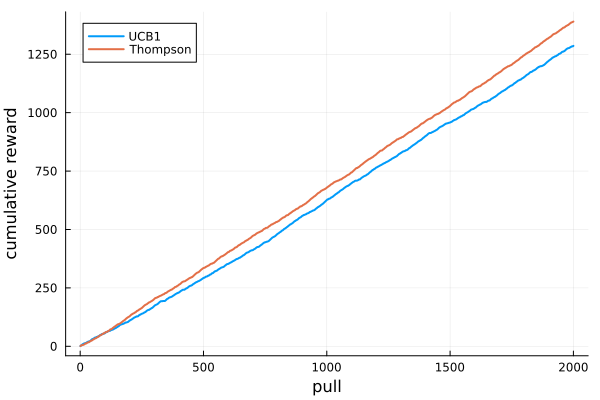

In [4]:
plot(ucb.cumulative_reward; lw = 2, label = "UCB1", xlabel = "pull", ylabel = "cumulative reward")
plot!(thompson.cumulative_reward; lw = 2, label = "Thompson")


## Summary

Both algorithms concentrate pulls on the best arm while continuing limited exploration. One seeded run is a reproducibility check, not a performance theorem; a serious comparison repeats many independent simulations and reports uncertainty.
